In [1]:
import os

import baltic as bt
from baltic import bt_utils

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

import numpy as np

def explodeTree(ax, treeFile):
    
    ll = bt.io.load_nexus(treeFile, 'time')
    ll.treeStats() ## report stats about tree
    ############
    
    admin2country = {
    'Bo': 'SLE', 'Bombali': 'SLE', 'Bonthe': 'SLE', 'Kailahun': 'SLE', 'Kambia': 'SLE', 'Kenema': 'SLE', 'Koinadugu': 'SLE', 'Kono': 'SLE', 'Moyamba': 'SLE', 'PortLoko': 'SLE', 'Pujehun': 'SLE', 'Tonkolili': 'SLE', 'WesternRural': 'SLE', 'WesternUrban': 'SLE', 
    'Bomi': 'LBR', 'Bong': 'LBR', 'Gbarpolu': 'LBR', 'GrandBassa': 'LBR', 'GrandCapeMount': 'LBR', 'GrandGedeh': 'LBR', 'GrandKru': 'LBR', 'Lofa': 'LBR', 'Margibi': 'LBR', 'Maryland': 'LBR', 'Montserrado': 'LBR', 'Nimba': 'LBR', 'RiverCess': 'LBR', 'RiverGee': 'LBR', 'Sinoe': 'LBR', 
    'Beyla': 'GIN', 'Boffa': 'GIN', 'Boke': 'GIN', 'Conakry': 'GIN', 'Coyah': 'GIN', 'Dabola': 'GIN', 'Dalaba': 'GIN', 'Dinguiraye': 'GIN', 'Dubreka': 'GIN', 'Faranah': 'GIN', 'Forecariah': 'GIN', 'Fria': 'GIN', 'Gaoual': 'GIN', 'Gueckedou': 'GIN', 'Kankan': 'GIN', 'Kerouane': 'GIN', 'Kindia': 'GIN', 'Kissidougou': 'GIN', 'Koubia': 'GIN', 'Koundara': 'GIN', 'Kouroussa': 'GIN', 'Labe': 'GIN', 'Lelouma': 'GIN', 'Lola': 'GIN', 'Macenta': 'GIN', 'Mali': 'GIN', 'Mamou': 'GIN', 'Mandiana': 'GIN', 'Nzerekore': 'GIN', 'Pita': 'GIN', 'Siguiri': 'GIN', 'Telimele': 'GIN', 'Tougue': 'GIN', 'Yamou': 'GIN', 
    'Kedougou': 'SEN', 'Salemata': 'SEN', 'Saraya': 'SEN', 'Velingara': 'SEN', 'Tambacounda': 'SEN', 
    'Kenieba': 'MLI', 'Kita': 'MLI', 'Kangaba': 'MLI', 'Kati': 'MLI', 'Yanfolila': 'MLI', 
    'Gabu': 'GNB', 'Tombali': 'GNB', 
    'SanPedro': 'CIV', 'Folon': 'CIV', 'Kabadougou': 'CIV', 'Cavally': 'CIV', 'Tonkpi': 'CIV', 'Bafing': 'CIV'
    } ## this dict translates location names in the tree to the corresponding country
    
    traitName = 'location.states' ## key used to access annotation of interest in tree
    countryFxn = lambda k: traitName in k.parent.traits and admin2country[k.traits[traitName]] != admin2country[k.parent.traits[traitName]] ## tree is exploded at either 1) root or 2) whenever there's a migration to another country
    
    subtreeSortFxn = lambda t: (-ord(admin2country[t.root.children[0].traits[traitName]][0]), -t.root.absoluteTime) ## split tree into conditionally-traversed subtrees
    
    colours = {'SLE': '#647397', 'GIN': '#6db69f', 'LBR': '#ea906e'}
    colourFxn = lambda k: colours[admin2country[k.traits[traitName]]]
    
    ################
    ll.plot_exploded_tree(ax, 
                          customFxn=countryFxn, 
                          subtreeSortFxn=subtreeSortFxn, 
                          colourFxn=colourFxn, 
                          pointSize=10, 
                          verticalSpace=10)

    bt_utils.clean_axes(ax)
    
    calendarTimeline = bt_utils.generate_calendar_timeline('2014-01-01', '2015-11-01')
    
    outputFmtFxn = lambda date: (bt_utils.convert_date_format(date, '%Y-%m-%d', '%b\n%Y') if bt_utils.convert_date_format(date, '%Y-%m-%d', '%m') == '01' else bt_utils.convert_date_format(date, '%Y-%m-%d', '%b')) if int(date.split('-')[1]) % 2 != 0 else ''

    bt_utils.format_time_grid(ax, calendarTimeline, outputFmtFxn=outputFmtFxn)
    bt_utils.plot_time_grid(ax, calendarTimeline)
    
    ax.tick_params(labelsize=14)
    
    ax.text(0.01, 0.01, 'A', size=46, ha='left', va='bottom', transform=ax.transAxes)
    
    ax.set_xlim(bt_utils.calendar_to_decimal_date('2014-01-01'), bt_utils.calendar_to_decimal_date('2015-11-01'))
    ax.set_ylim(-5, ll.ySpan + 320) ## need to guess y-axis limits
    
    return ax

In [2]:
def condenseTree(ax, treeFile):
    ll = bt.io.load_nexus(treeFile, 'time')
    ll.treeStats() ## report stats about tree
    
    ##########
    admin2country = {
    'Bo': 'SLE', 'Bombali': 'SLE', 'Bonthe': 'SLE', 'Kailahun': 'SLE', 'Kambia': 'SLE', 'Kenema': 'SLE', 'Koinadugu': 'SLE', 'Kono': 'SLE', 'Moyamba': 'SLE', 'PortLoko': 'SLE', 'Pujehun': 'SLE', 'Tonkolili': 'SLE', 'WesternRural': 'SLE', 'WesternUrban': 'SLE', 
    'Bomi': 'LBR', 'Bong': 'LBR', 'Gbarpolu': 'LBR', 'GrandBassa': 'LBR', 'GrandCapeMount': 'LBR', 'GrandGedeh': 'LBR', 'GrandKru': 'LBR', 'Lofa': 'LBR', 'Margibi': 'LBR', 'Maryland': 'LBR', 'Montserrado': 'LBR', 'Nimba': 'LBR', 'RiverCess': 'LBR', 'RiverGee': 'LBR', 'Sinoe': 'LBR', 
    'Beyla': 'GIN', 'Boffa': 'GIN', 'Boke': 'GIN', 'Conakry': 'GIN', 'Coyah': 'GIN', 'Dabola': 'GIN', 'Dalaba': 'GIN', 'Dinguiraye': 'GIN', 'Dubreka': 'GIN', 'Faranah': 'GIN', 'Forecariah': 'GIN', 'Fria': 'GIN', 'Gaoual': 'GIN', 'Gueckedou': 'GIN', 'Kankan': 'GIN', 'Kerouane': 'GIN', 'Kindia': 'GIN', 'Kissidougou': 'GIN', 'Koubia': 'GIN', 'Koundara': 'GIN', 'Kouroussa': 'GIN', 'Labe': 'GIN', 'Lelouma': 'GIN', 'Lola': 'GIN', 'Macenta': 'GIN', 'Mali': 'GIN', 'Mamou': 'GIN', 'Mandiana': 'GIN', 'Nzerekore': 'GIN', 'Pita': 'GIN', 'Siguiri': 'GIN', 'Telimele': 'GIN', 'Tougue': 'GIN', 'Yamou': 'GIN', 
    'Kedougou': 'SEN', 'Salemata': 'SEN', 'Saraya': 'SEN', 'Velingara': 'SEN', 'Tambacounda': 'SEN', 
    'Kenieba': 'MLI', 'Kita': 'MLI', 'Kangaba': 'MLI', 'Kati': 'MLI', 'Yanfolila': 'MLI', 
    'Gabu': 'GNB', 'Tombali': 'GNB', 
    'SanPedro': 'CIV', 'Folon': 'CIV', 'Kabadougou': 'CIV', 'Cavally': 'CIV', 'Tonkpi': 'CIV', 'Bafing': 'CIV'
    } ## this dict translates location names in the tree to the corresponding country
    ##########
    
    traitName = 'location.states' ## key used to access annotation of interest in tree
    
    colours = {'SLE': '#647397', 'GIN': '#6db69f', 'LBR': '#ea906e'}
    colourFxn = lambda k: colours[admin2country[k.traits[traitName]]]
    
    def partitionFxn(node):
        return admin2country[node.traits[traitName]] != admin2country[node.parent.traits[traitName]] ## evaluates to True on branches that migrate to another country
    
    pt = bt_utils.state_collapse_tree(ll, switchFxn=partitionFxn, keepLast=False, adjustEarlyHeights=True) ## keeping earliest branch as representative of lineage, adjusting its height to have the date of the last descendant
    pt.treeStats()
    
    padNodes = {k: np.log10(k.traits['size']) for k in pt.get_external()} ## this dict connects each tip in state-collapsed tree to a custom amount of y-axis space around that tip
    psFxn = lambda k: 10 + np.log(k.traits['size']) ** 4 ## this function scales tip circle sizes in state-collapsed using the 'size' value added to remaining tips' trait dicts 
    
    pt.plot_tree(ax, colourFxn=colourFxn, padNodes=padNodes, width=4, zorder=100)
    pt.plot_points(ax, colourFxn=colourFxn, padNodes=padNodes, pointSizeFxn=psFxn, zorder=101)
    
    bt_utils.clean_axes(ax)
    
    calendarTimeline = bt_utils.generate_calendar_timeline('2014-01-01', '2015-11-01')
    outputFmtFxn = lambda date: (bt_utils.convert_date_format(date, '%Y-%m-%d', '%b\n%Y') if bt_utils.convert_date_format(date, '%Y-%m-%d', '%m') == '01' else bt_utils.convert_date_format(date, '%Y-%m-%d', '%b')) if int(date.split('-')[1]) % 2 != 0 else ''

    bt_utils.format_time_grid(ax, calendarTimeline, outputFmtFxn=outputFmtFxn)
    bt_utils.plot_time_grid(ax, calendarTimeline)
    
    ax.tick_params(labelsize=14)

    ax.text(0.99, 0.01, 'B', size=46, ha='right', va='bottom', transform=ax.transAxes)
    
    ax.set_xlim(bt_utils.calendar_to_decimal_date('2014-01-01'), bt_utils.calendar_to_decimal_date('2015-12-01'))
    ax.set_ylim(0, pt.ySpan)
    
    return ax


Tree height: 1.772658
Tree length: 121.249284
strictly bifurcating tree
annotations present

Numbers of objects in tree: 3219 (1609 nodes and 1610 leaves)


Tree height: 1.772658
Tree length: 121.249284
strictly bifurcating tree
annotations present

Numbers of objects in tree: 3219 (1609 nodes and 1610 leaves)


Tree height: 1.772658
Tree length: 14.444496
multitype tree
annotations present

Numbers of objects in tree: 235 (204 nodes and 31 leaves)



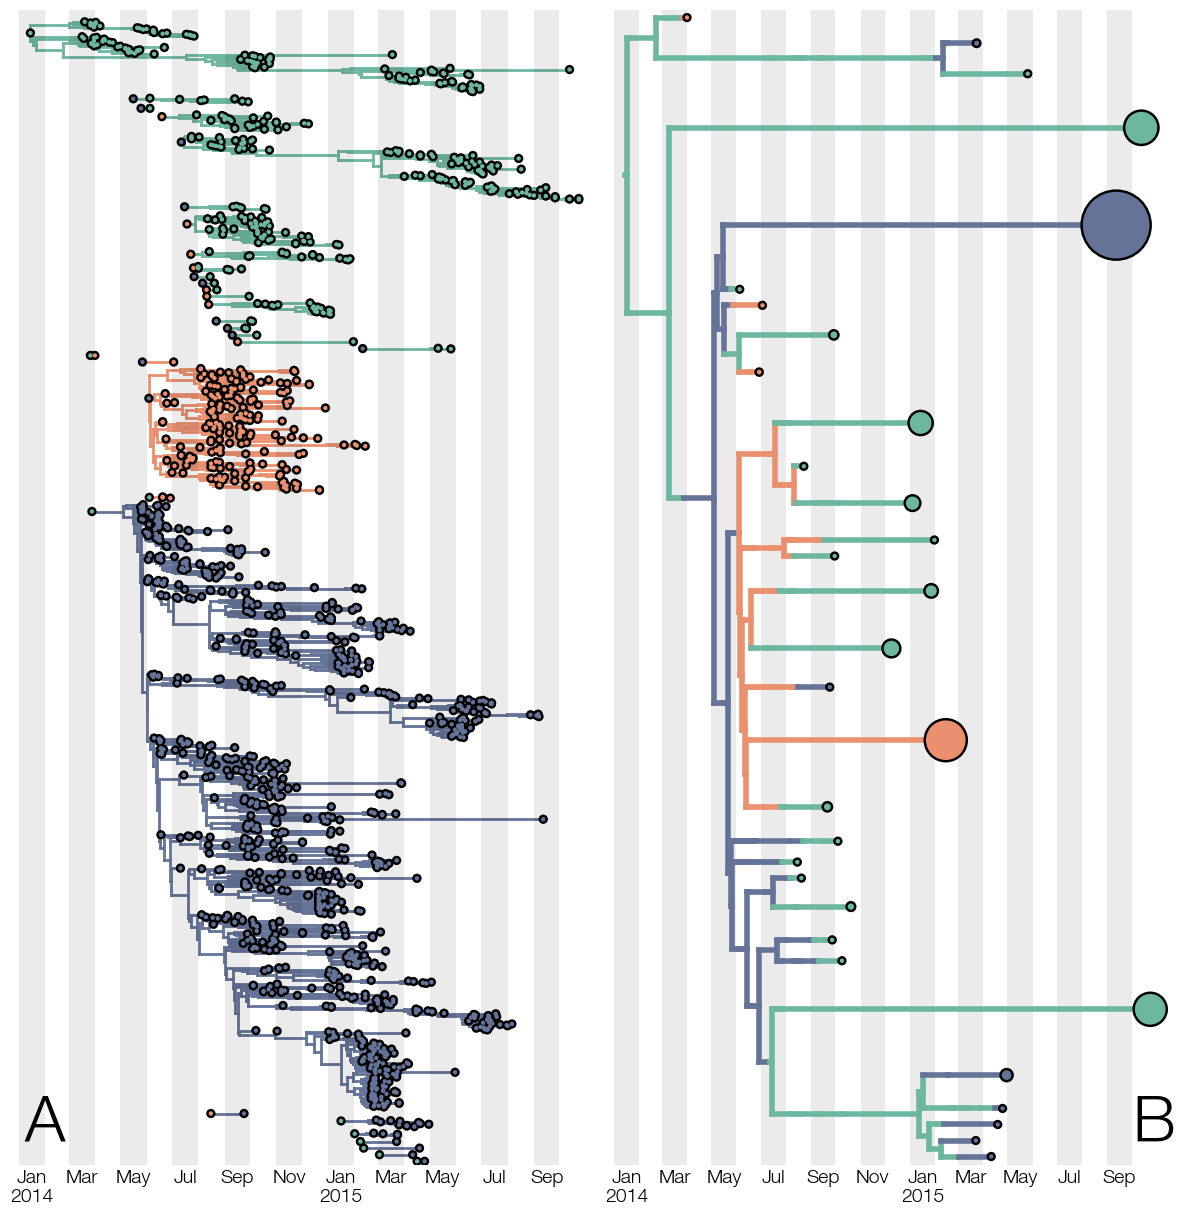

In [3]:
fig = plt.figure(figsize=(15, 15), facecolor='w')
gs = GridSpec(1, 2, wspace=0.05)

ax = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])


basePath = '/mnt/c/Users/evogytis/repos/baltic-v1-manuscript/'
treeFile = 'data/Fig3_explode-condense/Makona_1610_cds_ig.GLM.MCC.tree'

explodeTree(ax=ax, treeFile=os.path.join(basePath, treeFile))
condenseTree(ax=ax2, treeFile=os.path.join(basePath, treeFile))

plt.savefig(os.path.join(basePath, 'figures/Fig3_explode-condense.png'), bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(basePath, 'figures/Fig3_explode-condense.pdf'), bbox_inches='tight', dpi=300)
plt.show()